# Figure 3 — Single-shot observable error vs depth

**Paper location:** Section 6, Fig. 3.

## What this figure shows

That the cost advantage of Fig. 1 is realized at the level of a **physical
observable**, not just the abstract residual weight. We plot the error of the
steady-state expectation `⟨σ_y⟩` against controlled-evolution depth, log–log.

- **QPE** (exact) follows a power law and **plateaus** at moderate depth.
- **Rodeo (Gaussian)** is random per shot; we plot the **median** single-shot error
  with its 10–90% band (the mean is dominated by heavy tails when the normalization
  readout `R_I` passes near zero, so the median is the meaningful summary).
- **Rodeo (deterministic)** is exact and falls fastest.

Both Rodeo schedules cross below the QPE curve at moderate depth and keep falling,
reflecting the logarithmic-versus-power-law cost.

## Model & comparison

| | |
|---|---|
| **Model** | single spin, `h = 0.5`, `g = 1/2`; exact `⟨σ_y⟩_ss = 2/3` |
| **Compared** | QPE (exact) vs Rodeo deterministic (exact) vs Rodeo Gaussian (median + 10–90% band over random schedules) |
| **Quantity** | absolute observable error `|⟨σ_y⟩ − ⟨σ_y⟩_ss|` |
| **Readout** | ratio estimator `R_O / R_I` |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../reproduce/core"))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
C_QPE, C_RG, C_RD, GREY = "#0072B2", "#D55E00", "#009E73", "#BBBBBB"

from cost_compare import G, T0, qpe_depth
from qpe_filter import qpe_estimate
from rodeo_filter import rodeo_estimate, gaussian_schedule
from cost_compare import deterministic_schedule
from model import steady_state, sy
H, A_DET = 0.5, 3.0
T_RMS = 2.0 / G
rho,_,_ = steady_state(H); EXACT = np.trace(sy@rho).real
print(f"exact <sy>_ss = {EXACT:.4f}")


exact <sy>_ss = 0.6667


### Compute observable error for each filter\nQPE and deterministic Rodeo are exact; the Gaussian schedule is sampled to get the median and 10–90% spread.

In [2]:
ts = range(1,14)
qd  = np.array([qpe_depth(t) for t in ts])
qey = np.array([qpe_estimate(H,t,T0,sy) for t in ts])
err_q = np.abs(qey - EXACT)

ns = range(1,26)
rd_d  = np.array([np.sum(np.abs(deterministic_schedule(n,A_DET))) for n in ns])
rd_ey = np.array([rodeo_estimate(H, deterministic_schedule(n,A_DET), sy) for n in ns])
err_d = np.abs(rd_ey - EXACT)

rng = np.random.default_rng(23)
rg_d, rg_med, rg_lo, rg_hi = [], [], [], []
for n in ns:
    ests = np.array([rodeo_estimate(H, gaussian_schedule(n,T_RMS,rng), sy) for _ in range(2000)])
    e = np.abs(ests - EXACT)
    rg_d.append(n*T_RMS*np.sqrt(2/np.pi))
    rg_med.append(np.median(e)); rg_lo.append(np.percentile(e,10)); rg_hi.append(np.percentile(e,90))
rg_d,rg_med,rg_lo,rg_hi = map(np.array,(rg_d,rg_med,rg_lo,rg_hi))
print("computed QPE / Rodeo-det / Rodeo-Gauss errors")

computed QPE / Rodeo-det / Rodeo-Gauss errors


### Figure

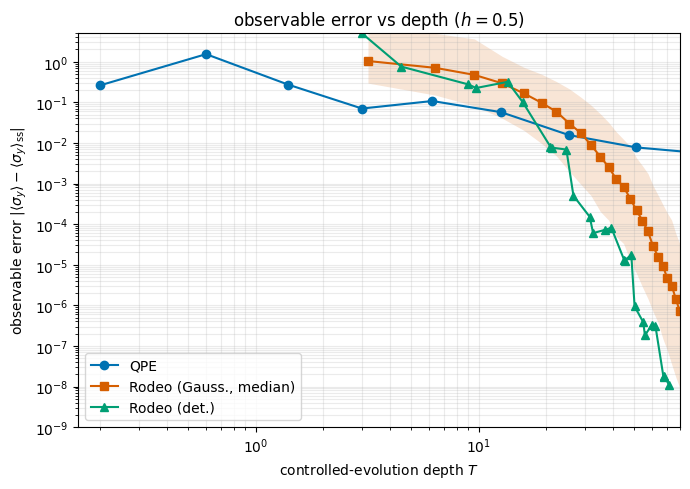

In [3]:
FLOOR=1e-9
fig,ax=plt.subplots(figsize=(7,5))
ax.fill_between(rg_d, np.clip(rg_lo,FLOOR,5), np.clip(rg_hi,FLOOR,5), color=C_RG, alpha=0.16, lw=0)
ax.loglog(qd,    np.clip(err_q,FLOOR,5), "o-", color=C_QPE, label="QPE")
ax.loglog(rg_d,  np.clip(rg_med,FLOOR,5),"s-", color=C_RG, label="Rodeo (Gauss., median)")
ax.loglog(rd_d,  np.clip(err_d,FLOOR,5), "^-", color=C_RD, label="Rodeo (det.)")
ax.set_xlim(qd.min()*0.8,80); ax.set_ylim(FLOOR,5)
ax.set_xlabel(r"controlled-evolution depth $T$")
ax.set_ylabel(r"observable error $|\langle\sigma_y\rangle-\langle\sigma_y\rangle_{\rm ss}|$")
ax.set_title(r"observable error vs depth ($h=0.5$)")
ax.legend(loc="lower left"); ax.grid(alpha=0.25,which="both")
fig.tight_layout(); fig.savefig("fig_obs_error.pdf",bbox_inches="tight"); plt.show()